# Data processing 

This notebook addresses overfitting by allowing drop out and reducing learning rate

In [1]:
!pip install split_folders

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [2]:
import matplotlib.pyplot as plt
import matplotlib.image as mping
import random
import splitfolders
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.layers.experimental import preprocessing

import os
import tensorflow as tf
from tensorflow.keras import layers


In [3]:
os.makedirs('output')
os.makedirs('output/train')
os.makedirs('output/val')
os.makedirs('output/test')

loc = "/kaggle/input/skin-diseases-image-dataset/IMG_CLASSES"

splitfolders.ratio(loc,output ="output",ratio = (0.80,.1,.1))

Copying files: 27153 files [06:39, 67.99 files/s] 


In [4]:


# Set this to your training folder path
train_dir = "./output/train"

# 1. Get all the class folder names and sort them alphabetically
class_names = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])
num_classes = len(class_names)

print(f"Total Number of Classes: {num_classes}\n")
print(f"{'Class Name':<60} | {'Image Count'}")
print("-" * 75)

# 2. Loop through each folder and count the files
total_images = 0
class_counts = {}

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    num_images = len(os.listdir(class_path))
    
    class_counts[class_name] = num_images
    total_images += num_images
    
    print(f"{class_name:<60} | {num_images}")

print("-" * 75)
print(f"{'TOTAL TRAINING IMAGES':<60} | {total_images}\n")

# Optional: Find the most and least represented classes
max_class = max(class_counts, key=class_counts.get)
min_class = min(class_counts, key=class_counts.get)
print(f"Largest Class:  {max_class} ({class_counts[max_class]} images)")
print(f"Smallest Class: {min_class} ({class_counts[min_class]} images)")

Total Number of Classes: 10

Class Name                                                   | Image Count
---------------------------------------------------------------------------
1. Eczema 1677                                               | 1341
10. Warts Molluscum and other Viral Infections - 2103        | 1682
2. Melanoma 15.75k                                           | 2512
3. Atopic Dermatitis - 1.25k                                 | 1005
4. Basal Cell Carcinoma (BCC) 3323                           | 2658
5. Melanocytic Nevi (NV) - 7970                              | 6376
6. Benign Keratosis-like Lesions (BKL) 2624                  | 1663
7. Psoriasis pictures Lichen Planus and related diseases - 2k | 1644
8. Seborrheic Keratoses and other Benign Tumors - 1.8k       | 1477
9. Tinea Ringworm Candidiasis and other Fungal Infections - 1.7k | 1361
---------------------------------------------------------------------------
TOTAL TRAINING IMAGES                                      

In [5]:
def random_image(val_dir,val_class):
    folder = val_dir +val_class
    random_image = random.sample(os.listdir(folder),1)
    img = mping.imread(folder + "/" + random_image[0])
    plt.imshow(img)
    plt.title(val_class)
    return img

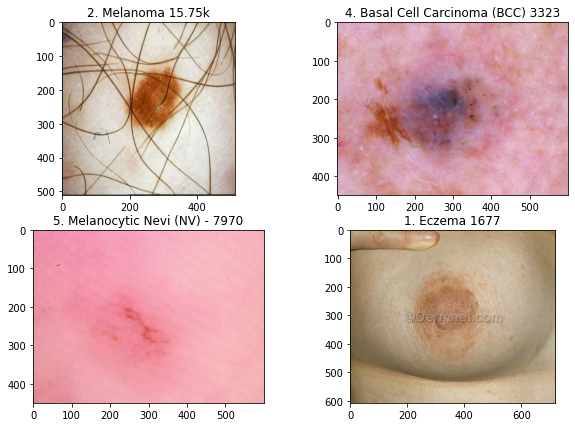

In [6]:
fig = plt.figure(figsize=(10, 7))
#Add an Axes to the figure as part of a subplot arrangement(Three integers (nrows, ncols, index).)
fig.add_subplot(2,2,1)
img_1 = random_image(val_dir = "./output/val/",val_class = "2. Melanoma 15.75k")
fig.add_subplot(2,2,2)
img_2 = random_image(val_dir = "./output/val/",val_class = "4. Basal Cell Carcinoma (BCC) 3323")
fig.add_subplot(2,2,3)
img_3 = random_image(val_dir = "./output/val/",val_class = "5. Melanocytic Nevi (NV) - 7970")
fig.add_subplot(2,2,4)
img4 = random_image(val_dir = "./output/val/",val_class = "1. Eczema 1677")


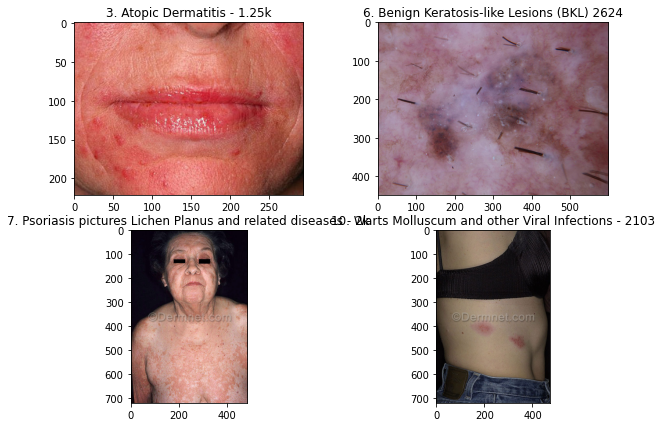

In [7]:
fig = plt.figure(figsize=(10, 7))
#Add an Axes to the figure as part of a subplot arrangement(Three integers (nrows, ncols, index).)
fig.add_subplot(2,2,1)
img_1 = random_image(val_dir = "./output/val/",val_class = "3. Atopic Dermatitis - 1.25k")
fig.add_subplot(2,2,2)
img_2 = random_image(val_dir = "./output/val/",val_class = "6. Benign Keratosis-like Lesions (BKL) 2624")
fig.add_subplot(2,2,3)
img_3 = random_image(val_dir = "./output/val/",val_class = "7. Psoriasis pictures Lichen Planus and related diseases - 2k")
fig.add_subplot(2,2,4)
img4 = random_image(val_dir = "./output/val/",val_class = "10. Warts Molluscum and other Viral Infections - 2103")

# Loading and Preparing Data 

In [9]:
from tensorflow.keras.preprocessing import image_dataset_from_directory

train_dir = "./output/train"
test_dir =  "./output/test"
val_dir = "./output/val"

train_data = image_dataset_from_directory(train_dir,label_mode = "categorical",
                                          image_size = (224,224),batch_size = 32,
                                         shuffle = True,seed = 42)
test_data = image_dataset_from_directory(test_dir,label_mode = "categorical",
                                          image_size = (224,224),batch_size = 32,
                                         shuffle = False,seed = 42)
val_data = image_dataset_from_directory(val_dir,label_mode = "categorical",
                                          image_size = (224,224),batch_size = 32,
                                         shuffle = False,seed = 42)



Found 21719 files belonging to 10 classes.
Found 2723 files belonging to 10 classes.
Found 2711 files belonging to 10 classes.


# EarlyStopping
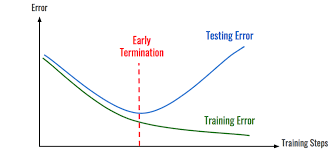

# ReduceLROnPlateau
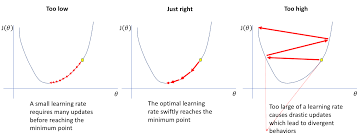

In [27]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=3, # If it doesn't improve for 3 epochs, kill it.
    restore_best_weights=True  # <--- THIS IS CRITICAL. It winds the clock back to the best epoch!
)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor = "val_loss",factor = 0.2,
                                                patience = 4,min_lr = 1e-7)


# Model Setup

### EfficientNetB7

> EfficientNet is a convolutional neural network architecture and scaling method that uniformly scales all dimensions of depth/width/resolution using a compound coefficient. Unlike conventional practice that arbitrary scales these factors, the EfficientNet scaling method uniformly scales network width, depth, and resolution with a set of fixed scaling coefficients




In [28]:
model = tf.keras.applications.EfficientNetB7(include_top = False)
model.trainable = False
#To "freeze" a layer means to exclude it from training, i.e. its weights will never be updated.

In [29]:

data_aug = tf.keras.Sequential([
    preprocessing.RandomWidth(0.2),
    preprocessing.RandomHeight(0.2),
    preprocessing.RandomRotation(0.2),
    preprocessing.RandomFlip("horizontal")
],name = "data_augmentation_layer")

In [30]:
inputs = layers.Input(shape = (224,224,3),name = "input_layer")
x = data_aug(inputs)
x = model(x)
x = layers.GlobalAvgPool2D(name = "pooling_layer")(x)
# parameter used to specify the size of the output generated from the layer.
x = layers.Dense(32,activation = "relu",kernel_initializer = tf.keras.initializers.he_normal())(x)

x = layers.Dropout(0.5)(x)

x = layers.Dense(10)(x)
outputs = layers.Activation("softmax",dtype = tf.float32)(x)
model = tf.keras.Model(inputs,outputs)
model.summary()

Model: "model_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_layer (InputLayer)     [(None, 224, 224, 3)]     0         
_________________________________________________________________
data_augmentation_layer (Seq (None, None, None, 3)     0         
_________________________________________________________________
efficientnetb7 (Functional)  (None, None, None, 2560)  64097687  
_________________________________________________________________
pooling_layer (GlobalAverage (None, 2560)              0         
_________________________________________________________________
dense_2 (Dense)              (None, 32)                81952     
_________________________________________________________________
dropout (Dropout)            (None, 32)                0         
_________________________________________________________________
dense_3 (Dense)              (None, 10)                330 

Once the model is created, you can config the model with 
* losses and metrics with model.compile(), 
* train the model with model.fit(),
* or use the model to do prediction with model.predict().

In [31]:

# 1. Get all the true labels from your training dataset
train_labels = []
for images, labels in train_data.unbatch():
    train_labels.append(np.argmax(labels.numpy()))

# 2. Calculate the optimal weights to balance the penalty
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

# 3. Convert to a dictionary for Keras
weight_dict = {i: weight for i, weight in enumerate(class_weights)}
print("Class Weights:", weight_dict)

Class Weights: {0: 1.6196122296793438, 1: 1.2912604042806184, 2: 0.8646098726114649, 3: 2.161094527363184, 4: 0.8171181339352896, 5: 0.34063676286072775, 6: 1.306013229104029, 7: 1.3211070559610705, 8: 1.4704807041299932, 9: 1.5958119030124909}


# Training

In [32]:
model.compile(loss = tf.keras.losses.CategoricalCrossentropy(),optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001),metrics = ["accuracy"])

In [33]:
history_1 = model.fit(train_data,epochs =20 , validation_data = val_data, 
                      callbacks = [early_stop,reduce_lr],class_weight=weight_dict)

Epoch 1/20
679/679 [==============================] - 353s 494ms/step - loss: 1.9421 - accuracy: 0.3140 - val_loss: 1.4122 - val_accuracy: 0.5522
Epoch 2/20
679/679 [==============================] - 329s 484ms/step - loss: 1.6618 - accuracy: 0.4359 - val_loss: 1.2673 - val_accuracy: 0.5651
Epoch 3/20
679/679 [==============================] - 329s 484ms/step - loss: 1.5595 - accuracy: 0.4671 - val_loss: 1.1900 - val_accuracy: 0.5920
Epoch 4/20
679/679 [==============================] - 328s 482ms/step - loss: 1.5001 - accuracy: 0.4918 - val_loss: 1.1379 - val_accuracy: 0.5954
Epoch 5/20
679/679 [==============================] - 327s 481ms/step - loss: 1.4513 - accuracy: 0.5012 - val_loss: 1.1115 - val_accuracy: 0.5946
Epoch 6/20
679/679 [==============================] - 326s 480ms/step - loss: 1.4231 - accuracy: 0.5111 - val_loss: 1.0888 - val_accuracy: 0.6005
Epoch 7/20
679/679 [==============================] - 330s 485ms/step - loss: 1.3934 - accuracy: 0.5194 - val_loss: 1.0641 -

In [34]:
print("Testing Accuracy",model.evaluate(test_data)) 

86/86 [==============================] - 36s 416ms/step - loss: 0.9449 - accuracy: 0.6460
Testing Accuracy [0.9448531866073608, 0.6459786891937256]


## Evaluation 

Extracting true labels and generating predictions...

CLASSIFICATION REPORT (Precision, Recall, F1-Score)
                                                                  precision    recall  f1-score   support

                                                  1. Eczema 1677       0.41      0.61      0.49       169
           10. Warts Molluscum and other Viral Infections - 2103       0.64      0.40      0.49       211
                                              2. Melanoma 15.75k       0.68      0.79      0.73       314
                                    3. Atopic Dermatitis - 1.25k       0.38      0.43      0.41       127
                              4. Basal Cell Carcinoma (BCC) 3323       0.78      0.84      0.81       333
                                 5. Melanocytic Nevi (NV) - 7970       0.90      0.76      0.82       797
                     6. Benign Keratosis-like Lesions (BKL) 2624       0.51      0.58      0.54       209
   7. Psoriasis pictures Lichen Planus and re

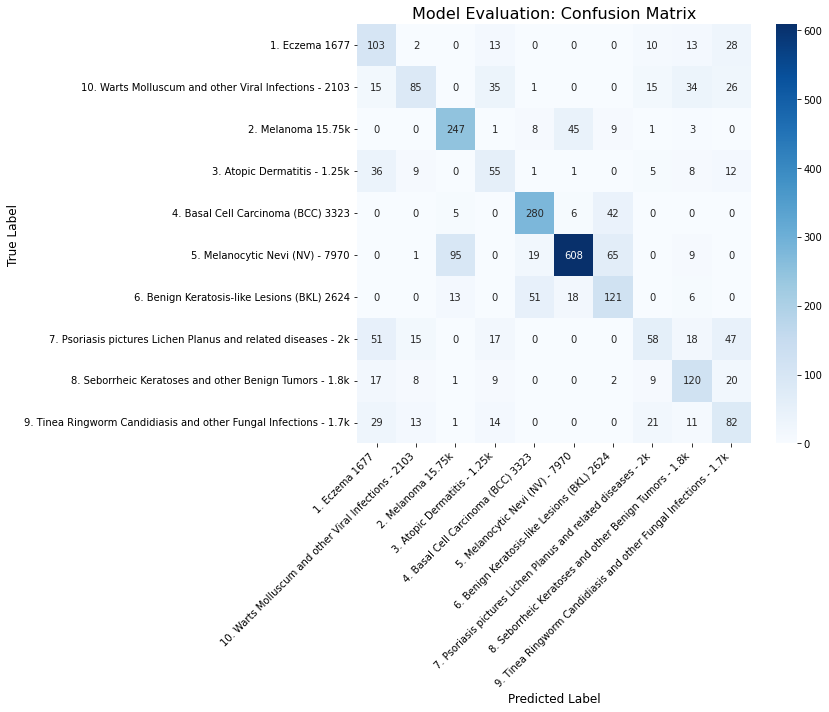

In [35]:


# 1. Choose which dataset to evaluate (usually test_data or val_data)
# Good job setting shuffle=False on these! That is required for accurate evaluation.
evaluation_data = test_data 
class_names = evaluation_data.class_names

print("Extracting true labels and generating predictions...")

# 2. Extract true labels from the dataset
y_true = []
for images, labels in evaluation_data:
    # Because of label_mode="categorical", we use argmax to convert one-hot arrays back to integer labels
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    
y_true = np.array(y_true)

# 3. Get the model's predictions
# The model outputs probabilities (softmax), so we use argmax to find the predicted class index
predictions = model.predict(evaluation_data)
y_pred = np.argmax(predictions, axis=1)

# 4. Print Precision, Recall, and F1-Score
print("\n" + "="*50)
print("CLASSIFICATION REPORT (Precision, Recall, F1-Score)")
print("="*50)
# classification_report handles all the heavy lifting for these metrics
report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

# 5. Generate and Plot the Confusion Matrix
print("\nGenerating Confusion Matrix...")
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Model Evaluation: Confusion Matrix', fontsize=16)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotates the x labels so they don't overlap
plt.tight_layout()
plt.show()

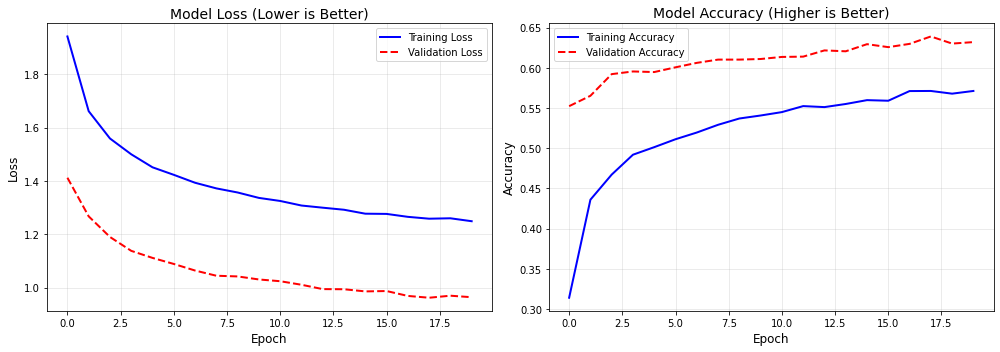

In [36]:
import matplotlib.pyplot as plt

# 1. Create a wide figure to hold two side-by-side graphs
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ==========================================
# GRAPH 1: LOSS (Using history_1)
# ==========================================
ax1.plot(history_1.history['loss'], label='Training Loss', color='blue', linewidth=2)
ax1.plot(history_1.history['val_loss'], label='Validation Loss', color='red', linewidth=2, linestyle='--')
ax1.set_title('Model Loss (Lower is Better)', fontsize=14)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

# ==========================================
# GRAPH 2: ACCURACY (Using history_1)
# ==========================================
ax2.plot(history_1.history['accuracy'], label='Training Accuracy', color='blue', linewidth=2)
ax2.plot(history_1.history['val_accuracy'], label='Validation Accuracy', color='red', linewidth=2, linestyle='--')
ax2.set_title('Model Accuracy (Higher is Better)', fontsize=14)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)

# Display the graphs beautifully
plt.tight_layout()
plt.show()

# Save Model

In [37]:
model.save('my_model.h5')

/opt/conda/lib/python3.7/site-packages/keras/utils/generic_utils.py:497: CustomMaskWarning: Custom mask layers require a config and must override get_config. When loading, the custom mask layer must be passed to the custom_objects argument.
  category=CustomMaskWarning)
